In [ ]:
"""
AWS Airlines Data Pipeline - Analysis Notebook

This notebook validates the ETL pipeline output and explores key insights
from the processed airline dataset.

Main goals:
1. Load cleaned output data
2. Validate ETL results
3. Check data quality
4. Explore engineered features
5. Surface a few business insights
"""

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import pyarrow
import glob


In [22]:
processed_path = Path("/Users/sezimzamirbekova/aws-data-pipeline/data/processed/airlines_clean.csv")

df = pd.read_csv(processed_path)

print(f"Loaded dataset shape: {df.shape}")
df.head()

Loaded dataset shape: (470722, 34)


,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,route,departure_time_bucket,arrival_time_bucket
0,2015,12,20,7,AA,2073,N742PS,LAX,IAD,1100,...,0,NaN,NaN,NaN,NaN,NaN,NaN,LAX_IAD,Morning,Evening
1,2015,12,20,7,AA,2133,N950UW,LGA,DCA,1100,...,0,NaN,NaN,NaN,NaN,NaN,NaN,LGA_DCA,Morning,Afternoon
2,2015,12,20,7,AA,2137,N967UW,BOS,LGA,1100,...,0,NaN,NaN,NaN,NaN,NaN,NaN,BOS_LGA,Morning,Morning
3,2015,12,20,7,AA,2163,N944UW,BOS,DCA,1100,...,0,NaN,NaN,NaN,NaN,NaN,NaN,BOS_DCA,Morning,Afternoon
4,2015,12,20,7,AA,795,N957UW,ATL,PHL,1100,...,0,NaN,NaN,NaN,NaN,NaN,NaN,ATL_PHL,Morning,Afternoon


In [25]:
# Before and after comparison
raw_files = glob.glob("/Users/sezimzamirbekova/aws-data-pipeline/data/raw/*.csv")

if raw_files:
    raw_df = pd.concat((pd.read_csv(f) for f in raw_files), ignore_index=True)

    summary_comparison = pd.DataFrame({
        "dataset": ["raw", "processed"],
        "rows": [len(raw_df), len(df)],
        "duplicates": [raw_df.duplicated().sum(), df.duplicated().sum()]
    })

    display(summary_comparison)
else:
    print("Raw CSV files not found. Skipping raw vs processed comparison.")

,dataset,rows,duplicates
0,raw,551508,72278
1,processed,470722,0


In [7]:
print("Columns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nSample rows:")
display(df.head())

Columns:
['YEAR', 'MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE', 'FLIGHT_NUMBER', 'TAIL_NUMBER', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'SCHEDULED_DEPARTURE', 'DEPARTURE_TIME', 'DEPARTURE_DELAY', 'TAXI_OUT', 'WHEELS_OFF', 'SCHEDULED_TIME', 'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE', 'WHEELS_ON', 'TAXI_IN', 'SCHEDULED_ARRIVAL', 'ARRIVAL_TIME', 'ARRIVAL_DELAY', 'DIVERTED', 'CANCELLED', 'CANCELLATION_REASON', 'AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY', 'route', 'departure_time_bucket', 'arrival_time_bucket']

Data types:
YEAR                       int64
MONTH                      int64
DAY                        int64
DAY_OF_WEEK                int64
AIRLINE                   object
FLIGHT_NUMBER              int64
TAIL_NUMBER               object
ORIGIN_AIRPORT            object
DESTINATION_AIRPORT       object
SCHEDULED_DEPARTURE        int64
DEPARTURE_TIME             int64
DEPARTURE_DELAY          float64
TAXI_OUT                 float64
WHE

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,route,departure_time_bucket,arrival_time_bucket
0,2015,12,20,7,AA,2073,N742PS,LAX,IAD,1100,...,0,NaN,NaN,NaN,NaN,NaN,NaN,LAX_IAD,Morning,Evening
1,2015,12,20,7,AA,2133,N950UW,LGA,DCA,1100,...,0,NaN,NaN,NaN,NaN,NaN,NaN,LGA_DCA,Morning,Afternoon
2,2015,12,20,7,AA,2137,N967UW,BOS,LGA,1100,...,0,NaN,NaN,NaN,NaN,NaN,NaN,BOS_LGA,Morning,Morning
3,2015,12,20,7,AA,2163,N944UW,BOS,DCA,1100,...,0,NaN,NaN,NaN,NaN,NaN,NaN,BOS_DCA,Morning,Afternoon
4,2015,12,20,7,AA,795,N957UW,ATL,PHL,1100,...,0,NaN,NaN,NaN,NaN,NaN,NaN,ATL_PHL,Morning,Afternoon


In [8]:
# Summarize the dataset
print("Row count:", len(df))
print("Column count:", len(df.columns))

print("\nMissing values by column:")
display(df.isnull().sum().sort_values(ascending=False))

print("\nDuplicate rows:", df.duplicated().sum())

Row count: 470722
Column count: 34

Missing values by column:


CANCELLATION_REASON      470722
WEATHER_DELAY            373972
LATE_AIRCRAFT_DELAY      373972
AIRLINE_DELAY            373972
SECURITY_DELAY           373972
AIR_SYSTEM_DELAY         373972
ARRIVAL_DELAY              1059
AIR_TIME                   1059
ELAPSED_TIME               1059
SCHEDULED_ARRIVAL             0
ARRIVAL_TIME                  0
YEAR                          0
DIVERTED                      0
CANCELLED                     0
WHEELS_ON                     0
route                         0
departure_time_bucket         0
TAXI_IN                       0
DISTANCE                      0
MONTH                         0
SCHEDULED_TIME                0
WHEELS_OFF                    0
TAXI_OUT                      0
DEPARTURE_DELAY               0
DEPARTURE_TIME                0
SCHEDULED_DEPARTURE           0
DESTINATION_AIRPORT           0
ORIGIN_AIRPORT                0
TAIL_NUMBER                   0
FLIGHT_NUMBER                 0
AIRLINE                       0
DAY_OF_W


Duplicate rows: 0


In [9]:
display(df.describe(include="all").transpose())

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
YEAR,470722.0,NaN,NaN,NaN,2015.0,0.0,2015.0,2015.0,2015.0,2015.0,2015.0
MONTH,470722.0,NaN,NaN,NaN,12.0,0.0,12.0,12.0,12.0,12.0,12.0
DAY,470722.0,NaN,NaN,NaN,15.85327,8.894637,1.0,8.0,16.0,23.0,31.0
DAY_OF_WEEK,470722.0,NaN,NaN,NaN,3.852928,1.935952,1.0,2.0,4.0,5.0,7.0
AIRLINE,470722,13,WN,105771,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FLIGHT_NUMBER,470722.0,NaN,NaN,NaN,2144.867654,1729.57618,1.0,725.0,1732.0,3074.0,8445.0
TAIL_NUMBER,470722,4414,N493HA,383,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ORIGIN_AIRPORT,470722,307,ATL,30732,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DESTINATION_AIRPORT,470722,307,ATL,30740,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SCHEDULED_DEPARTURE,470722.0,NaN,NaN,NaN,1327.469802,488.365418,1.0,915.0,1325.0,1730.0,2359.0


In [11]:
required_columns = [
    "DEPARTURE_TIME",
    "ARRIVAL_TIME",
    "ORIGIN_AIRPORT",
    "DESTINATION_AIRPORT",
    "route",
    "departure_time_bucket",
    "arrival_time_bucket"
]

missing_required = [col for col in required_columns if col not in df.columns]

if missing_required:
    print("Missing required columns:", missing_required)
else:
    print("All required engineered columns are present.")

All required engineered columns are present.


In [12]:
# Validate time ranges
invalid_departure_times = df[(df["DEPARTURE_TIME"] < 0) | (df["DEPARTURE_TIME"] > 2359)]
invalid_arrival_times = df[(df["ARRIVAL_TIME"] < 0) | (df["ARRIVAL_TIME"] > 2359)]
print("Invalid departure_time rows:", len(invalid_departure_times))
print("Invalid arrival_time rows:", len(invalid_arrival_times))

Invalid departure_time rows: 0
Invalid arrival_time rows: 207


In [13]:
# Explore top routes by flight count
top_routes = (
    df["route"]
    .value_counts()
    .head(10)
    .reset_index()
)

top_routes.columns = ["route", "flight_count"]
display(top_routes)

,route,flight_count
0,SFO_LAX,1333
1,LAX_SFO,1313
2,JFK_LAX,975
3,LAX_JFK,971
4,LAX_LAS,897
5,LAS_LAX,894
6,LGA_ORD,782
7,ORD_LGA,778
8,ATL_MCO,777
9,MCO_ATL,770


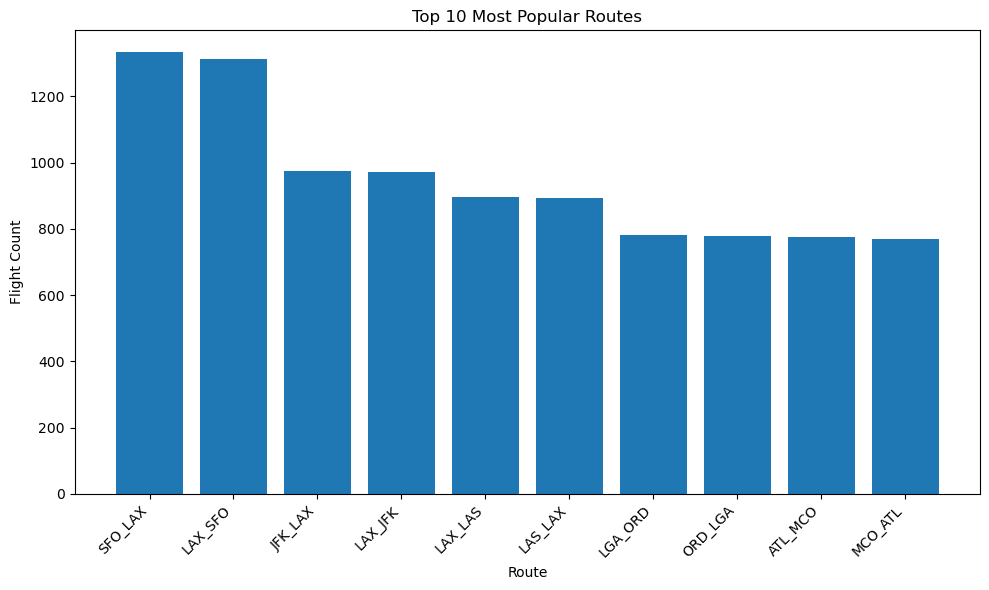

In [14]:
# Plot top 10 routes
plt.figure(figsize=(10, 6))
plt.bar(top_routes["route"], top_routes["flight_count"])
plt.xticks(rotation=45, ha="right")
plt.title("Top 10 Most Popular Routes")
plt.xlabel("Route")
plt.ylabel("Flight Count")
plt.tight_layout()
plt.show()

In [15]:
# Departure time bucket distribution
bucket_counts = (
    df["departure_time_bucket"]
    .value_counts()
    .reset_index()
)

bucket_counts.columns = ["departure_time_bucket", "count"]
display(bucket_counts)

,departure_time_bucket,count
0,Morning,187925
1,Afternoon,140039
2,Evening,137455
3,Night,5303


In [16]:
# Arrival time bucket distribution
bucket_counts = (
    df["arrival_time_bucket"]
    .value_counts()
    .reset_index()
)

bucket_counts.columns = ["arrival_time_bucket", "count"]
display(bucket_counts)

,arrival_time_bucket,count
0,Evening,182242
1,Afternoon,141863
2,Morning,131213
3,Night,15197
4,Unknown,207


In [37]:
# Analyze departure delay
avg_delay_by_dep_bucket = (
        df.groupby("departure_time_bucket")["DEPARTURE_DELAY"]
        .mean()
        .sort_values(ascending=False)
        .reset_index()
    )
avg_delay_by_dep_bucket.columns = ["departure_time_bucket", "avg_departure_delay"]
display(avg_delay_by_dep_bucket)


,departure_time_bucket,avg_departure_delay
0,Night,52.397699
1,Evening,19.791314
2,Afternoon,12.862667
3,Morning,3.788602


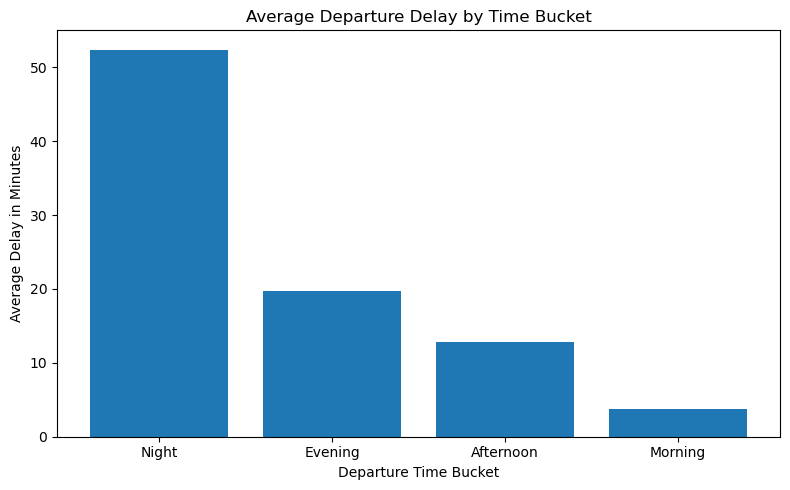

In [ ]:
# Plot average departure delay by time bucket
plt.figure(figsize=(8, 5))
plt.bar(avg_delay_by_dep_bucket["departure_time_bucket"], avg_delay_by_dep_bucket["avg_departure_delay"])
plt.title("Average Departure Delay by Time Bucket")
plt.xlabel("Departure Time Bucket")
plt.ylabel("Average Delay in Minutes")
plt.tight_layout()
plt.show()

In [30]:
# Analyze arrival delay
avg_delay_by_arr_bucket = (
        df.groupby("arrival_time_bucket")["ARRIVAL_DELAY"]
        .mean()
        .sort_values(ascending=False)
        .reset_index()
    )
avg_delay_by_arr_bucket.columns = ["arrival_time_bucket", "avg_arrival_delay"]
display(avg_delay_by_arr_bucket)

,arrival_time_bucket,avg_arrival_delay
0,Night,51.792390
1,Unknown,22.724638
2,Evening,10.403239
3,Afternoon,4.141777
4,Morning,-3.086063


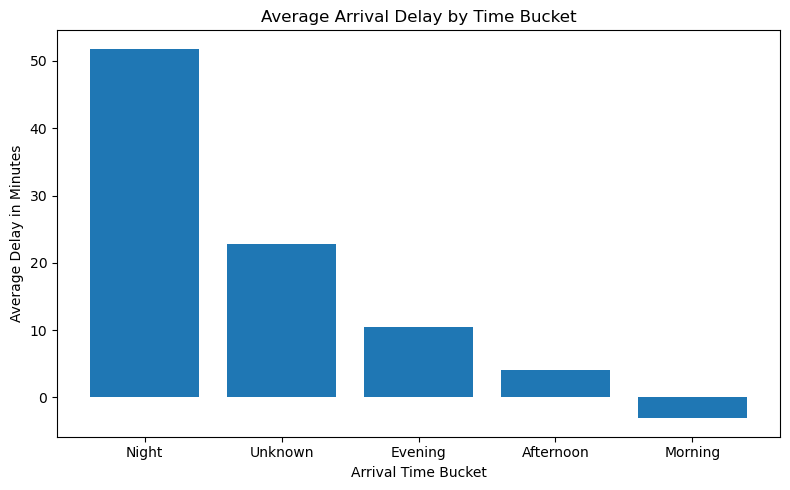

In [32]:
# Plot average arrival delay by time bucket
plt.figure(figsize=(8, 5))
plt.bar(avg_delay_by_arr_bucket["arrival_time_bucket"], avg_delay_by_arr_bucket["avg_arrival_delay"])
plt.title("Average Arrival Delay by Time Bucket")
plt.xlabel("Arrival Time Bucket")
plt.ylabel("Average Delay in Minutes")
plt.tight_layout()
plt.show()

In [38]:
# Key insights summary
print("Key Insights")
print("------------")

print(f"1. Final processed dataset contains {len(df):,} rows and {len(df.columns)} columns.")

print("2. The ETL pipeline successfully created engineered features such as 'route' and 'departure_time_bucket'.")

print(f"3. Top route: {top_routes.iloc[0]['route']} with {top_routes.iloc[0]['flight_count']} flights.")

highest_delay_bucket = avg_delay_by_dep_bucket.iloc[0]
print(
        f"5. Highest average departure delay occurs in the "
        f"{highest_delay_bucket['departure_time_bucket']} bucket "
        f"({highest_delay_bucket['avg_departure_delay']:.2f} minutes)."
    )

Key Insights
------------
1. Final processed dataset contains 470,722 rows and 34 columns.
2. The ETL pipeline successfully created engineered features such as 'route' and 'departure_time_bucket'.
3. Top route: SFO_LAX with 1333 flights.
5. Highest average departure delay occurs in the Night bucket (52.40 minutes).


In [39]:
print("""
Conclusion:
This notebook validates the AWS ETL pipeline output and demonstrates that the
processed dataset is ready for downstream analytics. The pipeline successfully
cleaned the source data, removed duplicates, created useful engineered features,
and enabled analysis of routes, airport activity, and delay patterns.
""")


Conclusion:
This notebook validates the AWS ETL pipeline output and demonstrates that the
processed dataset is ready for downstream analytics. The pipeline successfully
cleaned the source data, removed duplicates, created useful engineered features,
and enabled analysis of routes, airport activity, and delay patterns.

